In [10]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated,Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage

In [11]:
generatorllm=ChatOpenAI()
evaluatorllm=ChatOpenAI()
optimizerllm=ChatOpenAI()


In [12]:
class TweetEvaluation(BaseModel):
    evaluation: Literal['approved','needs_improvement'] =Field(..., description="Final Evaluation Result")

    feedback:str =Field(...,description="Constructive  feedback for the tweet")

In [13]:
structured_evaluator_llm=evaluatorllm.with_structured_output(TweetEvaluation)

c:\Users\navee\Documents\langgraph\myenv\Lib\site-packages\langchain_openai\chat_models\base.py:2418: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [14]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved","needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int

In [15]:
def generate_tweet(state:TweetState):
    messages = [
        SystemMessage(
        content="""
        You are a funny X (Twitter) tweet writer.
        Create humorous, engaging, and witty tweets.
        Keep tweets concise, creative, and under 280 characters.
        """
    ),
        HumanMessage(
        content=f"""
        Generate a funny tweet about the following topic:

        {state['topic']}
        """
    )
    ]
    response=generatorllm.invoke(messages).content
    return {'tweet':response}



In [16]:
def evaluate_tweet(state:TweetState):
    messages = [
        SystemMessage(
        content="""
        You are an expert X (Twitter) content evaluator.
        Analyze tweets for humor, engagement, clarity, creativity,
        and viral potential.
        Provide constructive feedback and a score out of 10.
        """
    ),
        HumanMessage(
        content=f"""
        Evaluate the following tweet:

        {state['tweet']}
        """
    )
]
    response=structured_evaluator_llm.invoke(messages)

    return {'feedback':response.feedback,'evolution':response.evaluation}

    


In [17]:
def optimize_tweet(state:TweetState):
    messages = [
        SystemMessage(
        content="""
        You are an expert X (Twitter) content optimizer.

        Your job is to improve tweets based on feedback.
        Make tweets more engaging, funny, concise, and likely to go viral.

        Use the feedback to rewrite the tweet.
        Return only the improved tweet.
        """
    ),
        HumanMessage(
        content=f"""
        Original Tweet:
        {state['tweet']}

        Feedback:
        {state['feedback']}

        Rewrite the tweet based on the feedback.
        """
    )
]
    
    response=optimizerllm.invoke(messages).content
    iteration=state['iteration'] + 1

    return {'tweet':response,'iteration':iteration}

In [20]:
def route_evaluation(state: TweetState):
    if state['evaluation'] == 'approved' or state['iteration']>=state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement' 

In [21]:
graph=StateGraph(TweetState)

graph.add_node('generate_tweet',generate_tweet)
graph.add_node('evaluate_tweet',evaluate_tweet)
graph.add_node('optimize_tweet',optimize_tweet)

graph.add_edge(START,'generate_tweet')
graph.add_edge('generate_tweet','evaluate_tweet')
graph.add_conditional_edges('evaluate_tweet',route_evaluation,{'approved':END,'needs_improvement':'optimize_tweet'})

graph.add_edge('optimize_tweet','evaluate_tweet')

workflow=graph.compile()


In [23]:
intial_state={'topic':'Agentic Ai','iteration':1,'max_iteration':5}
final_state=workflow.invoke(intial_state)


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

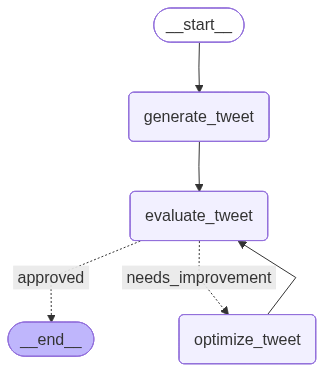

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
